### Prova A1 - Machine Learning
### Aluna - Lais Gabrielly Vital Medeiros
### Previsão de cancelamento de reservas de hotel


## Questão 1 — Definição do problema e entendimento do dataset


### a) Origem e descrição dos dados

Escolhi o **Hotel Reservations Dataset**, publicado por Ahsan Raza no Kaggle. O conjunto tem **36.275 registros e 19 colunas**, e cada linha representa uma reserva de hotel. Ele contém informações sobre hóspedes, estadia, quarto, antecedência e cancelamento.

Fonte: https://www.kaggle.com/datasets/ahsan81/hotel-reservations-classification-dataset

A quantidade informada corresponde à base original, antes da limpeza.


### b) Problema e categoria

Defini como objetivo prever se uma reserva será cancelada usando as informações disponíveis antes do resultado da reserva. Isso pode ajudar o hotel a identificar reservas com maior risco de cancelamento e organizar sua ocupação.

O problema é de **classificação binária**, porque existem duas respostas: `Canceled` (cancelada) e `Not_Canceled` (não cancelada).


In [145]:
dataset_nome = "Hotel Reservations Dataset"
dataset_url = "https://www.kaggle.com/datasets/ahsan81/hotel-reservations-classification-dataset"
tipo_problema = "Classificação binária"
objetivo = "Prever se uma reserva de hotel será cancelada."

print("Dataset:", dataset_nome)
print("Fonte:", dataset_url)
print("Tipo:", tipo_problema)
print("Objetivo:", objetivo)


Dataset: Hotel Reservations Dataset
Fonte: https://www.kaggle.com/datasets/ahsan81/hotel-reservations-classification-dataset
Tipo: Classificação binária
Objetivo: Prever se uma reserva de hotel será cancelada.


### c) Principais variáveis e atributos do modelo

Organizei as variáveis disponíveis e sua função no projeto.

| Variável | Significado | Uso inicial |
|---|---|---|
| `Booking_ID` | Identificador da reserva | Excluir do modelo |
| `no_of_adults` | Número de adultos | Atributo |
| `no_of_children` | Número de crianças | Atributo |
| `no_of_weekend_nights` | Noites de fim de semana reservadas | Atributo |
| `no_of_week_nights` | Noites em dias de semana reservadas | Atributo |
| `type_of_meal_plan` | Plano de alimentação | Atributo |
| `required_car_parking_space` | Necessidade de estacionamento | Atributo |
| `room_type_reserved` | Tipo de quarto reservado | Atributo |
| `lead_time` | Dias entre a reserva e a chegada prevista | Atributo |
| `arrival_year` | Ano da chegada prevista | Atributo |
| `arrival_month` | Mês da chegada prevista | Atributo |
| `arrival_date` | Dia do mês da chegada prevista | Atributo |
| `market_segment_type` | Segmento ou canal da reserva | Atributo |
| `repeated_guest` | Indica se o hóspede já esteve no hotel | Atributo |
| `no_of_previous_cancellations` | Cancelamentos anteriores do hóspede | Atributo |
| `no_of_previous_bookings_not_canceled` | Reservas anteriores não canceladas | Atributo |
| `avg_price_per_room` | Preço médio por quarto | Atributo |
| `no_of_special_requests` | Quantidade de pedidos especiais | Atributo |
| `booking_status` | Resultado da reserva | Variável alvo |

Identifiquei 19 variáveis na base. Não usei `Booking_ID` como atributo porque ele apenas identifica a reserva. Separei `booking_status` como alvo e usei as outras 17 variáveis como atributos.

Defini a previsão com informações disponíveis antes do resultado da reserva. Não encontrei documentação suficiente para confirmar quando preço e pedidos especiais foram atualizados; considerei isso uma limitação do projeto.

Separei os nomes dos atributos numéricos e categóricos. Nesta etapa, defini a seleção dos atributos.


In [146]:
atributos_numericos = [
    "no_of_adults",
    "no_of_children",
    "no_of_weekend_nights",
    "no_of_week_nights",
    "required_car_parking_space",
    "lead_time",
    "arrival_year",
    "arrival_month",
    "arrival_date",
    "repeated_guest",
    "no_of_previous_cancellations",
    "no_of_previous_bookings_not_canceled",
    "avg_price_per_room",
    "no_of_special_requests",
]

atributos_categoricos = [
    "type_of_meal_plan",
    "room_type_reserved",
    "market_segment_type",
]

atributos_modelo = atributos_numericos + atributos_categoricos
print("Quantidade de atributos selecionados:", len(atributos_modelo))


Quantidade de atributos selecionados: 17


### d) Variável alvo

A variável alvo é **`booking_status`**. Representei `Not_Canceled` por **0** e `Canceled` por **1**, para que o cancelamento seja a classe positiva na avaliação.

Defini o nome do alvo e o mapeamento das classes. Apliquei essa conversão na preparação dos dados.


In [147]:
variavel_alvo = "booking_status"
mapeamento_classes = {"Not_Canceled": 0, "Canceled": 1}

print("Variável alvo:", variavel_alvo)
print("Classes:", mapeamento_classes)


Variável alvo: booking_status
Classes: {'Not_Canceled': 0, 'Canceled': 1}


### e) Clusterização
Este item não se aplica: escolhi classificação para prever o resultado da reserva, sem formar clusters.


### f) Algoritmos escolhidos e justificativa

Comparei três algoritmos de classificação:

- **Regressão logística:** foi minha referência inicial por ser um modelo simples. Ela pode prever as duas classes deste problema.
- **Árvore de decisão:** pode encontrar regras envolvendo antecedência, preço e outras características. Também facilita a explicação das decisões do modelo.
- **Random Forest:** combina várias árvores e pode aprender relações mais complexas entre os atributos. Controlei sua complexidade para evitar um modelo pesado ou muito ajustado ao treino.

Os três são adequados porque trabalham com classificação em dados tabulares, após a transformação das variáveis categóricas. Escolhi o modelo pelos resultados da comparação.

Comparei os modelos com validação cruzada no treino e usei o F1 da classe cancelada como critério principal, acompanhado de precisão e recall. Separei o teste para a avaliação final do modelo escolhido.

Documentação dos algoritmos:
- https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
- https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
- https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

Registrei os nomes dos três algoritmos comparados.


In [148]:
algoritmos_planejados = [
    "Regressão logística",
    "Árvore de decisão",
    "Random Forest",
]

for algoritmo in algoritmos_planejados:
    print(algoritmo)


Regressão logística
Árvore de decisão
Random Forest


## Questão 2 — Preparação e tratamento dos dados

### Análise inicial
Carreguei o CSV e conferi o tamanho, os tipos das colunas e alguns exemplos de reservas.


In [149]:
from pathlib import Path
import pandas as pd
from IPython.display import display

caminho_dataset = Path("dataset/Hotel Reservations.csv")
dados = pd.read_csv(caminho_dataset)
print("Linhas e colunas:", dados.shape)
display(dados.head())
dados.info()
display(dados.describe().T)


Linhas e colunas: (36275, 19)


,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


<class 'pandas.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  str    
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  str    
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  str    
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date              

,count,mean,std,min,25%,50%,75%,max
no_of_adults,36275.0,1.844962,0.518715,0.0,2.0,2.00,2.0,4.0
no_of_children,36275.0,0.105279,0.402648,0.0,0.0,0.00,0.0,10.0
no_of_weekend_nights,36275.0,0.810724,0.870644,0.0,0.0,1.00,2.0,7.0
no_of_week_nights,36275.0,2.204300,1.410905,0.0,1.0,2.00,3.0,17.0
required_car_parking_space,36275.0,0.030986,0.173281,0.0,0.0,0.00,0.0,1.0
lead_time,36275.0,85.232557,85.930817,0.0,17.0,57.00,126.0,443.0
arrival_year,36275.0,2017.820427,0.383836,2017.0,2018.0,2018.00,2018.0,2018.0
arrival_month,36275.0,7.423653,3.069894,1.0,5.0,8.00,10.0,12.0
arrival_date,36275.0,15.596995,8.740447,1.0,8.0,16.00,23.0,31.0
repeated_guest,36275.0,0.025637,0.158053,0.0,0.0,0.00,0.0,1.0


### Valores ausentes e duplicatas
Conferi valores ausentes, registros repetidos e a proporção de cancelamentos.
Também verifiquei reservas parecidas que possuem IDs diferentes.


In [150]:
display(dados.isna().sum().rename("Valores ausentes").to_frame())
print("Linhas totalmente duplicadas:", dados.duplicated().sum())
print("IDs repetidos:", dados["Booking_ID"].duplicated().sum())
print("Repetições sem considerar o ID:", dados.drop(columns="Booking_ID").duplicated().sum())

resumo_classes = dados["booking_status"].value_counts().to_frame("Quantidade")
resumo_classes["Percentual"] = dados["booking_status"].value_counts(normalize=True) * 100
display(resumo_classes.round(2))
for coluna in atributos_categoricos:
    display(dados[coluna].value_counts().rename(coluna).to_frame())


,Valores ausentes
Booking_ID,0
no_of_adults,0
no_of_children,0
no_of_weekend_nights,0
no_of_week_nights,0
type_of_meal_plan,0
required_car_parking_space,0
room_type_reserved,0
lead_time,0
arrival_year,0


Linhas totalmente duplicadas: 0
IDs repetidos: 0
Repetições sem considerar o ID: 10275


,Quantidade,Percentual
booking_status,,
Not_Canceled,24390,67.24
Canceled,11885,32.76


,type_of_meal_plan
type_of_meal_plan,
Meal Plan 1,27835
Not Selected,5130
Meal Plan 2,3305
Meal Plan 3,5


,room_type_reserved
room_type_reserved,
Room_Type 1,28130
Room_Type 4,6057
Room_Type 6,966
Room_Type 2,692
Room_Type 5,265
Room_Type 7,158
Room_Type 3,7


,market_segment_type
market_segment_type,
Online,23214
Offline,10528
Corporate,2017
Complementary,391
Aviation,125


### Tipos e valores inconsistentes
A base tem 36.275 reservas e nenhum valor ausente. Conferi os tipos numéricos, as datas e valores que precisam de atenção.


In [151]:
dados_limpos = dados.copy()
for coluna in atributos_numericos:
    dados_limpos[coluna] = pd.to_numeric(dados_limpos[coluna], errors="coerce")
for coluna in atributos_categoricos + [variavel_alvo]:
    dados_limpos[coluna] = dados_limpos[coluna].str.strip()

colunas_necessarias = atributos_modelo + [variavel_alvo, "Booking_ID"]
if not set(colunas_necessarias).issubset(dados_limpos.columns):
    raise ValueError("O CSV não contém todas as colunas esperadas.")
if not dados_limpos[variavel_alvo].isin(mapeamento_classes).all():
    raise ValueError("Existem resultados de reserva desconhecidos.")

data_chegada = pd.to_datetime(
    {"year": dados_limpos["arrival_year"],
     "month": dados_limpos["arrival_month"],
     "day": dados_limpos["arrival_date"]},
    errors="coerce",
)
sem_hospedes = (dados_limpos["no_of_adults"] + dados_limpos["no_of_children"]) == 0
sem_noites = (dados_limpos["no_of_weekend_nights"] + dados_limpos["no_of_week_nights"]) == 0
valores_negativos = (dados_limpos[atributos_numericos] < 0).any(axis=1)
print("Datas inválidas:", data_chegada.isna().sum())
print("Reservas sem hóspedes:", sem_hospedes.sum())
print("Reservas sem noites:", sem_noites.sum())
print("Linhas com valores negativos:", valores_negativos.sum())
print("Reservas com preço zero:", dados_limpos["avg_price_per_room"].eq(0).sum())


Datas inválidas: 37
Reservas sem hóspedes: 0
Reservas sem noites: 78
Linhas com valores negativos: 0
Reservas com preço zero: 545


### Limpeza dos registros
Removi datas inválidas e reservas sem noites. Mantive preços iguais a zero, pois podem representar estadias gratuitas.
Mantive reservas com IDs diferentes, mesmo quando seus atributos eram iguais.


In [152]:
linhas_invalidas = data_chegada.isna() | sem_hospedes | sem_noites | valores_negativos
dados_limpos = dados_limpos.loc[~linhas_invalidas].drop_duplicates().copy()
print("Linhas originais:", len(dados))
print("Linhas removidas:", len(dados) - len(dados_limpos))
print("Linhas após a limpeza:", len(dados_limpos))
if len(dados_limpos) < 30000:
    raise ValueError("A base ficou com menos de 30 mil linhas.")


Linhas originais: 36275
Linhas removidas: 115
Linhas após a limpeza: 36160


A base tinha **36.275 reservas e 19 colunas**, com informações sobre hóspedes, estadia, preço e cancelamento. Existem colunas numéricas e categóricas, como tipo de quarto e plano de alimentação.

Não encontrei valores ausentes, linhas totalmente duplicadas nem IDs repetidos. Sem considerar o ID, apareceram **10.275 repetições**. Mantive esses registros porque reservas diferentes podem ter as mesmas características.

**67,24% das reservas não foram canceladas e 32,76% foram canceladas.** Como existem mais reservas não canceladas, avaliei também se o modelo conseguiu identificar os cancelamentos.

Encontrei **37 datas inválidas, 78 reservas sem noites e 545 preços iguais a zero**. Removi as datas inválidas e as reservas sem noites. Mantive os preços zero porque podem representar estadias gratuitas, e não tenho informação suficiente para dizer que são erros.

No total, removi **115 registros** e fiquei com **36.160 reservas**.


### Divisão entre treino e teste
Separei cerca de 80% para treino e 20% para teste, tentando manter a proporção das classes.
Mantive juntas as reservas com os mesmos atributos para evitar repetições entre treino e teste.


In [153]:
from sklearn.model_selection import StratifiedGroupKFold

X = dados_limpos[atributos_modelo].copy()
y = dados_limpos[variavel_alvo].map(mapeamento_classes).astype(int)

grupos = pd.util.hash_pandas_object(X, index=False)
divisor = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
indices_treino, indices_teste = next(divisor.split(X, y, groups=grupos))

X_treino, X_teste = X.iloc[indices_treino].copy(), X.iloc[indices_teste].copy()
y_treino, y_teste = y.iloc[indices_treino].copy(), y.iloc[indices_teste].copy()
grupos_treino = grupos.iloc[indices_treino].copy()
grupos_teste = grupos.iloc[indices_teste].copy()

assert set(grupos_treino).isdisjoint(set(grupos_teste))
print("Reservas de treino:", len(X_treino))
print("Reservas de teste:", len(X_teste))
display(pd.DataFrame({
    "Base limpa (%)": y.value_counts(normalize=True) * 100,
    "Treino (%)": y_treino.value_counts(normalize=True) * 100,
    "Teste (%)": y_teste.value_counts(normalize=True) * 100,
}).rename(index={0: "Não cancelada", 1: "Cancelada"}).round(2))


Reservas de treino: 28928
Reservas de teste: 7232


,Base limpa (%),Treino (%),Teste (%)
booking_status,,,
Não cancelada,67.16,67.16,67.16
Cancelada,32.84,32.84,32.84


### Valores discrepantes


Usei o intervalo interquartil para identificar valores extremos apenas nos dados de treino.
Analisei esses valores, mas não os removi automaticamente, porque reservas caras ou longas podem ser reais.


In [154]:
colunas_outliers = ["lead_time", "avg_price_per_room", "no_of_week_nights",
                    "no_of_weekend_nights", "no_of_children",
                    "no_of_previous_cancellations", "no_of_previous_bookings_not_canceled"]
q1 = X_treino[colunas_outliers].quantile(0.25)
q3 = X_treino[colunas_outliers].quantile(0.75)
iqr = q3 - q1
extremos = ((X_treino[colunas_outliers] < q1 - 1.5 * iqr) |
            (X_treino[colunas_outliers] > q3 + 1.5 * iqr)).sum()
display(extremos.rename("Valores extremos no treino").to_frame())


,Valores extremos no treino
lead_time,1152
avg_price_per_room,1292
no_of_week_nights,261
no_of_weekend_nights,15
no_of_children,2152
no_of_previous_cancellations,284
no_of_previous_bookings_not_canceled,643


### Pré-processamento
Mantive extremos válidos e não apliquei SMOTE, pois o desbalanceamento é moderado.
Transformei as categorias e preparei a imputação; usei padronização apenas na regressão logística.


In [155]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def criar_preprocessador(padronizar=False):
    etapas_numericas = [("imputacao", SimpleImputer(strategy="median"))]
    if padronizar:
        etapas_numericas.append(("padronizacao", StandardScaler()))

    pipeline_numerico = Pipeline(etapas_numericas)
    pipeline_categorico = Pipeline([
        ("imputacao", SimpleImputer(strategy="most_frequent")),
        ("categorias", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer([
        ("numericas", pipeline_numerico, atributos_numericos),
        ("categoricas", pipeline_categorico, atributos_categoricos),
    ], remainder="drop")



Mesmo sem valores ausentes na base atual, preparei o preenchimento com a mediana nas colunas numéricas e a categoria mais frequente nas categóricas.
O OneHotEncoder transforma categorias em números. A padronização coloca os números em escalas semelhantes para a regressão logística.
Ajustei as transformações somente no treino, dentro da Pipeline, para evitar usar informações do teste.


### Decisões da preparação
Mantive os 17 atributos e 36.160 reservas. Usei uma Pipeline em cada modelo para aprender as transformações apenas no treino.
Preparei esse fluxo para uso na API. A divisão que fiz avalia perfis diferentes, sem simular meses futuros.

Não usei Booking_ID porque ele apenas identifica a reserva. Mantive os outros 17 atributos por terem relação com o problema, sem criar novas variáveis nesta etapa. Não apliquei balanceamento. Comparei os modelos também pela capacidade de identificar a classe cancelada.


## Questão 3 — Construção e treinamento do modelo

### 1º algoritmo: Regressão logística
Testei primeiro a regressão logística, usando os atributos preparados na questão 2.
Escolhi esse algoritmo como referência inicial, porque é simples e permite estimar a probabilidade de cada classe.

### Criação do modelo
Juntei a preparação e o algoritmo em uma Pipeline. Assim, cada divisão da validação aprende suas próprias transformações.
Usei `C=1.0` como regularização inicial, `lbfgs` como método de ajuste e até 2.000 iterações para permitir a convergência.


In [156]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

modelo_logistica = Pipeline([
    ("preprocessamento", criar_preprocessador(padronizar=True)),
    ("classificador", LogisticRegression(
        C=1.0,
        solver="lbfgs",
        max_iter=2000,
        class_weight=None,
        random_state=42,
    )),
])
modelo_logistica


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessamento', ...), ('classificador', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('categoricas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold

### Validação nos dados de treino
Usei cinco divisões, mantendo reservas com atributos iguais no mesmo grupo. Reutilizei essas divisões nos outros algoritmos.
Medi F1, precisão, recall e acurácia. Usei o F1 da classe cancelada como principal critério de comparação.


In [157]:
from sklearn.model_selection import StratifiedGroupKFold, cross_validate

validacao = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
divisoes_validacao = list(validacao.split(X_treino, y_treino, groups=grupos_treino))
metricas_validacao = {
    "f1": "f1",
    "precisao": "precision",
    "recall": "recall",
    "acuracia": "accuracy",
}

validacao_logistica = cross_validate(
    modelo_logistica,
    X_treino,
    y_treino,
    cv=divisoes_validacao,
    scoring=metricas_validacao,
    n_jobs=1,
    error_score="raise",
)

resultados_logistica = pd.DataFrame({
    metrica: validacao_logistica[f"test_{metrica}"]
    for metrica in metricas_validacao
}, index=pd.Index(range(1, 6), name="Divisão"))
display(resultados_logistica.round(4))
resumo_logistica = resultados_logistica.agg(["mean", "std"]).T
resumo_logistica.columns = ["Média", "Desvio padrão"]
display(resumo_logistica.round(4))


,f1,precisao,recall,acuracia
Divisão,,,,
1,0.6696,0.7609,0.5979,0.8063
2,0.6940,0.7444,0.6500,0.8118
3,0.7045,0.7439,0.6691,0.8156
4,0.6534,0.7226,0.5963,0.7922
5,0.6956,0.7372,0.6584,0.8107


,Média,Desvio padrão
f1,0.6834,0.0212
precisao,0.7418,0.0138
recall,0.6344,0.0347
acuracia,0.8073,0.0091


### Treinamento da regressão logística
Depois da validação, ajustei a Pipeline com todo o conjunto de treino.
Nesta etapa, mantive o teste reservado e não exportei o modelo.


In [158]:
modelo_logistica.fit(X_treino, y_treino)

iteracoes_logistica = int(modelo_logistica.named_steps["classificador"].n_iter_.max())
print("Regressão logística treinada com", len(X_treino), "reservas.")
print("Iterações usadas no ajuste:", iteracoes_logistica)
print("Conjunto de teste reservado:", len(X_teste), "reservas.")

comparacao_modelos = pd.DataFrame([{
    "Algoritmo": "Regressão logística",
    "F1 médio": resultados_logistica["f1"].mean(),
    "Precisão média": resultados_logistica["precisao"].mean(),
    "Recall médio": resultados_logistica["recall"].mean(),
    "Acurácia média": resultados_logistica["acuracia"].mean(),
    "Desvio padrão do F1": resultados_logistica["f1"].std(),
}])
display(comparacao_modelos.round(4))


Regressão logística treinada com 28928 reservas.
Iterações usadas no ajuste: 65
Conjunto de teste reservado: 7232 reservas.


,Algoritmo,F1 médio,Precisão média,Recall médio,Acurácia média,Desvio padrão do F1
0,Regressão logística,0.6834,0.7418,0.6344,0.8073,0.0212


### Entendimento do primeiro resultado

Na validação, a regressão logística teve **80,73% de acurácia**, ou seja, acertou cerca de 81 em cada 100 reservas. Porém, esse resultado sozinho não mostra se o modelo identifica bem os cancelamentos.

A **precisão foi de 74,18%**: quando o modelo indicou cancelamento, acertou aproximadamente 74 em cada 100 alertas. O **recall foi de 63,44%**, mostrando que encontrou cerca de 63 em cada 100 cancelamentos reais e deixou passar aproximadamente 37.

O **F1 foi de 68,34%**, combinando precisão e recall. Entendi que o modelo serve como referência inicial, mas ainda deixa passar uma parte dos cancelamentos.


### 2º algoritmo: Árvore de decisão
A árvore aprende regras a partir dos atributos das reservas e pode encontrar relações que a regressão logística não consegue representar diretamente.
Usei os mesmos dados de treino e transformei as categorias, sem padronizar os números.

### Criação do modelo
Limitei a profundidade a 8 e exigi pelo menos 20 reservas em cada folha para reduzir o risco de decorar o treino.
Usei o critério Gini e `random_state=42` para repetir o experimento; esses parâmetros são uma configuração inicial.


In [159]:
from sklearn.tree import DecisionTreeClassifier

modelo_arvore = Pipeline([
    ("preprocessamento", criar_preprocessador(padronizar=False)),
    ("classificador", DecisionTreeClassifier(
        criterion="gini",
        max_depth=8,
        min_samples_leaf=20,
        class_weight=None,
        random_state=42,
    )),
])
modelo_arvore


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessamento', ...), ('classificador', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('categoricas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold

### Validação da árvore de decisão
Reutilizei as cinco divisões e as métricas do primeiro algoritmo para comparar os dois de forma justa.
Ajustei a preparação dentro de cada divisão, sem usar o conjunto de teste.


In [160]:
validacao_arvore = cross_validate(
    modelo_arvore,
    X_treino,
    y_treino,
    cv=divisoes_validacao,
    scoring=metricas_validacao,
    n_jobs=1,
    error_score="raise",
)

resultados_arvore = pd.DataFrame({
    metrica: validacao_arvore[f"test_{metrica}"]
    for metrica in metricas_validacao
}, index=pd.Index(range(1, 6), name="Divisão"))
display(resultados_arvore.round(4))
resumo_arvore = resultados_arvore.agg(["mean", "std"]).T
resumo_arvore.columns = ["Média", "Desvio padrão"]
display(resumo_arvore.round(4))


,f1,precisao,recall,acuracia
Divisão,,,,
1,0.6972,0.7702,0.6368,0.8184
2,0.7437,0.7833,0.7079,0.8398
3,0.7819,0.8127,0.7533,0.8619
4,0.6952,0.7212,0.6711,0.8067
5,0.7660,0.7950,0.7389,0.8517


,Média,Desvio padrão
f1,0.7368,0.0395
precisao,0.7765,0.0347
recall,0.7016,0.0480
acuracia,0.8357,0.0229


### Treinamento e comparação
Ajustei a árvore com todo o treino e acrescentei seus resultados à comparação.
Mantive o teste reservado e só escolhi o modelo depois de testar os três algoritmos.


In [161]:
modelo_arvore.fit(X_treino, y_treino)
print("Árvore treinada com", len(X_treino), "reservas.")
print("Profundidade:", modelo_arvore.named_steps["classificador"].get_depth())
print("Quantidade de folhas:", modelo_arvore.named_steps["classificador"].get_n_leaves())

comparacao_modelos = comparacao_modelos.loc[
    comparacao_modelos["Algoritmo"] != "Árvore de decisão"
].copy()
comparacao_modelos = pd.concat([
    comparacao_modelos,
    pd.DataFrame([{
        "Algoritmo": "Árvore de decisão",
        "F1 médio": resultados_arvore["f1"].mean(),
        "Precisão média": resultados_arvore["precisao"].mean(),
        "Recall médio": resultados_arvore["recall"].mean(),
        "Acurácia média": resultados_arvore["acuracia"].mean(),
        "Desvio padrão do F1": resultados_arvore["f1"].std(),
    }]),
], ignore_index=True)
display(comparacao_modelos.sort_values("F1 médio", ascending=False).round(4))


Árvore treinada com 28928 reservas.
Profundidade: 8
Quantidade de folhas: 121


,Algoritmo,F1 médio,Precisão média,Recall médio,Acurácia média,Desvio padrão do F1
1,Árvore de decisão,0.7368,0.7765,0.7016,0.8357,0.0395
0,Regressão logística,0.6834,0.7418,0.6344,0.8073,0.0212


### Entendimento do segundo resultado

A árvore teve **83,57% de acurácia**, **77,65% de precisão** e **70,16% de recall** na validação. Isso significa que cerca de 78 em cada 100 alertas estavam certos e que o modelo encontrou cerca de 70 em cada 100 cancelamentos reais.

O **F1 foi de 73,68%**, uma diferença de **5,34 pontos percentuais acima** da regressão logística. Esse resultado mostra que a árvore teve um equilíbrio melhor entre precisão e recall nesta comparação.


### 3º algoritmo: Random Forest
O Random Forest combina várias árvores para prever o cancelamento. Cada árvore aprende com uma amostra do treino e parte dos atributos.
Usei os mesmos dados e a mesma preparação da árvore de decisão, sem padronizar os números.

### Criação do modelo
Usei 200 árvores, profundidade máxima de 12 e pelo menos 5 reservas por folha para controlar a complexidade.
Usei `max_features="sqrt"` para variar os atributos entre as árvores e `random_state=42` para repetir o experimento.


In [162]:
from sklearn.ensemble import RandomForestClassifier

modelo_floresta = Pipeline([
    ("preprocessamento", criar_preprocessador(padronizar=False)),
    ("classificador", RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=5,
        max_features="sqrt",
        class_weight=None,
        random_state=42,
        n_jobs=1,
    )),
])
modelo_floresta


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessamento', ...), ('classificador', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('categoricas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold

### Validação do Random Forest
Usei as mesmas cinco divisões e métricas dos modelos anteriores. Ajustei o pré-processamento dentro de cada divisão.
Esses parâmetros são uma configuração inicial; ainda não representam uma busca por todas as configurações possíveis.


In [163]:
validacao_floresta = cross_validate(
    modelo_floresta,
    X_treino,
    y_treino,
    cv=divisoes_validacao,
    scoring=metricas_validacao,
    n_jobs=1,
    error_score="raise",
)

resultados_floresta = pd.DataFrame({
    metrica: validacao_floresta[f"test_{metrica}"]
    for metrica in metricas_validacao
}, index=pd.Index(range(1, 6), name="Divisão"))
display(resultados_floresta.round(4))
resumo_floresta = resultados_floresta.agg(["mean", "std"]).T
resumo_floresta.columns = ["Média", "Desvio padrão"]
display(resumo_floresta.round(4))


,f1,precisao,recall,acuracia
Divisão,,,,
1,0.7195,0.8452,0.6263,0.8396
2,0.7669,0.8315,0.7116,0.8579
3,0.7869,0.8636,0.7228,0.8714
4,0.7142,0.7804,0.6584,0.8270
5,0.7660,0.8528,0.6953,0.8605


,Média,Desvio padrão
f1,0.7507,0.0321
precisao,0.8347,0.0325
recall,0.6829,0.0399
acuracia,0.8513,0.0178


### Treinamento e comparação dos três modelos
Treinei o Random Forest com todo o treino e comparei os três modelos pelo F1 médio da classe cancelada.
Mantive o conjunto de teste separado da escolha do modelo.


In [164]:
modelo_floresta.fit(X_treino, y_treino)
print("Random Forest treinado com", len(X_treino), "reservas.")
print("Quantidade de árvores:", len(modelo_floresta.named_steps["classificador"].estimators_))

comparacao_modelos = comparacao_modelos.loc[
    comparacao_modelos["Algoritmo"] != "Random Forest"
].copy()
comparacao_modelos = pd.concat([
    comparacao_modelos,
    pd.DataFrame([{
        "Algoritmo": "Random Forest",
        "F1 médio": resultados_floresta["f1"].mean(),
        "Precisão média": resultados_floresta["precisao"].mean(),
        "Recall médio": resultados_floresta["recall"].mean(),
        "Acurácia média": resultados_floresta["acuracia"].mean(),
        "Desvio padrão do F1": resultados_floresta["f1"].std(),
    }]),
], ignore_index=True).sort_values("F1 médio", ascending=False).reset_index(drop=True)
display(comparacao_modelos.round(4))

modelos_treinados = {
    "Regressão logística": modelo_logistica,
    "Árvore de decisão": modelo_arvore,
    "Random Forest": modelo_floresta,
}
nome_modelo_escolhido = comparacao_modelos.iloc[0]["Algoritmo"]
modelo_escolhido = modelos_treinados[nome_modelo_escolhido]
print("Modelo escolhido pelo maior F1 médio:", nome_modelo_escolhido)


Random Forest treinado com 28928 reservas.
Quantidade de árvores: 200


,Algoritmo,F1 médio,Precisão média,Recall médio,Acurácia média,Desvio padrão do F1
0,Random Forest,0.7507,0.8347,0.6829,0.8513,0.0321
1,Árvore de decisão,0.7368,0.7765,0.7016,0.8357,0.0395
2,Regressão logística,0.6834,0.7418,0.6344,0.8073,0.0212


Modelo escolhido pelo maior F1 médio: Random Forest


### Entendimento do terceiro resultado

O Random Forest teve **85,13% de acurácia**, **83,47% de precisão** e **68,29% de recall** na validação. Isso significa que cerca de 83 em cada 100 alertas estavam certos e que o modelo encontrou cerca de 68 em cada 100 cancelamentos reais.

O **F1 foi de 75,07%**. Comparando os três modelos, o **Random Forest** teve o maior F1 médio, de **75,07%**, e foi escolhido para a avaliação final.

Essa escolha vale para os modelos e configurações testados. As diferenças entre as divisões também precisam ser consideradas; o resultado não garante que o modelo será sempre melhor em outros dados.


## Questão 4 — Avaliação e interpretação dos resultados

### Panorama dos três algoritmos
Comparei as médias das mesmas cinco divisões da validação no treino. Usei o F1 da classe cancelada como critério principal.
O gráfico também mostra precisão, recall e acurácia para entender as diferenças entre os modelos.


,F1 médio,Precisão média,Recall médio,Acurácia média
Algoritmo,,,,
Random Forest,75.07,83.47,68.29,85.13
Árvore de decisão,73.68,77.65,70.16,83.57
Regressão logística,68.34,74.18,63.44,80.73


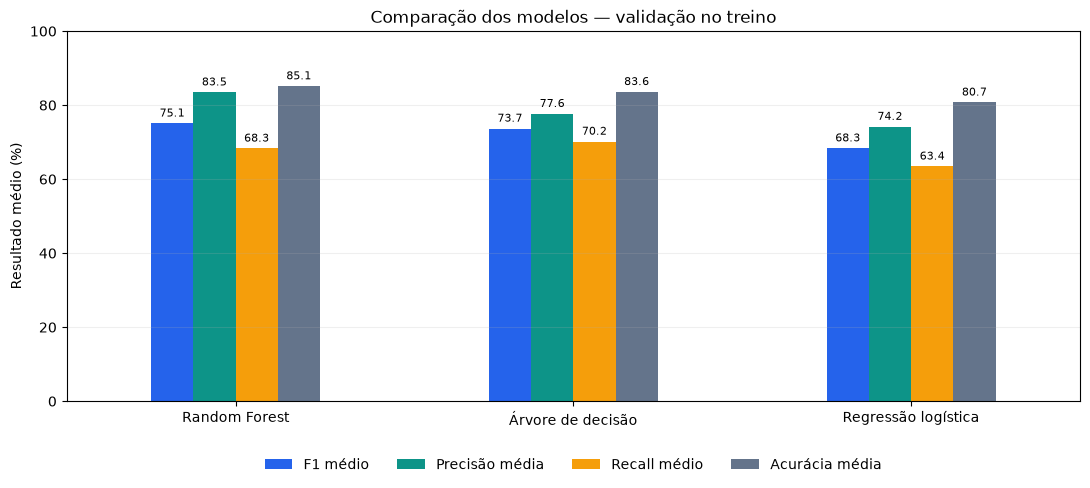

In [165]:
import matplotlib.pyplot as plt

colunas_metricas = ["F1 médio", "Precisão média", "Recall médio", "Acurácia média"]
panorama = comparacao_modelos.set_index("Algoritmo")[colunas_metricas] * 100
display(panorama.round(2))

ax = panorama.plot.bar(figsize=(11, 5), color=["#2563eb", "#0d9488", "#f59e0b", "#64748b"])
for barras in ax.containers:
    ax.bar_label(barras, fmt="%.1f", fontsize=8, padding=3)
ax.set(title="Comparação dos modelos — validação no treino",
       ylabel="Resultado médio (%)", xlabel="", ylim=(0, 100))
ax.tick_params(axis="x", rotation=0)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=4, frameon=False)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()


### O que entendi da comparação
O Random Forest teve o maior F1 médio (**75,07%**), seguido da árvore (**73,68%**) e da regressão logística (**68,34%**). Por esse critério, escolhi o Random Forest.

A árvore teve recall maior (**70,16% contra 68,29%**), mas o Random Forest teve precisão maior (**83,47% contra 77,65%**). Assim, ele produziu uma proporção menor de alertas falsos entre os alertas emitidos.

A diferença de F1 entre os dois melhores é pequena e os resultados variaram entre as divisões. A escolha segue o critério definido, sem garantir superioridade em todos os cenários.

### Avaliação final do modelo escolhido
Usei o teste reservado para avaliar o modelo escolhido pela validação, sem usar seus resultados para ajustar parâmetros.
Calculei as métricas com o limite padrão de 0,5 para cancelamento e usei as probabilidades na ROC/AUC.


In [166]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
)

previsoes_teste = modelo_escolhido.predict(X_teste)
indice_cancelada = list(modelo_escolhido.classes_).index(1)
probabilidades_teste = modelo_escolhido.predict_proba(X_teste)[:, indice_cancelada]

metricas_teste = pd.Series({
    "Acurácia": accuracy_score(y_teste, previsoes_teste),
    "Precisão": precision_score(y_teste, previsoes_teste, zero_division=0),
    "Recall": recall_score(y_teste, previsoes_teste, zero_division=0),
    "F1": f1_score(y_teste, previsoes_teste, zero_division=0),
    "ROC/AUC": roc_auc_score(y_teste, probabilidades_teste),
}, name="Resultado")
print("Modelo avaliado:", nome_modelo_escolhido)
print("Reservas no teste:", len(X_teste))
display(metricas_teste.to_frame().round(4))


Modelo avaliado: Random Forest
Reservas no teste: 7232


,Resultado
Acurácia,0.8428
Precisão,0.8049
Recall,0.6880
F1,0.7419
ROC/AUC,0.9080


### O que entendi das métricas no teste

No teste, o Random Forest teve **84,28% de acurácia** e **74,19% de F1**. A precisão foi **80,49%**, e o recall foi **68,80%**.

Isso significa que cerca de 80 em cada 100 alertas estavam certos e que o modelo encontrou cerca de 69 em cada 100 cancelamentos reais. Esses resultados são do teste e podem ser diferentes das médias da validação.


### Matriz de confusão
Mostrei quantas reservas foram classificadas corretamente e onde o modelo errou.
As linhas representam o resultado real, e as colunas representam a previsão do Random Forest.


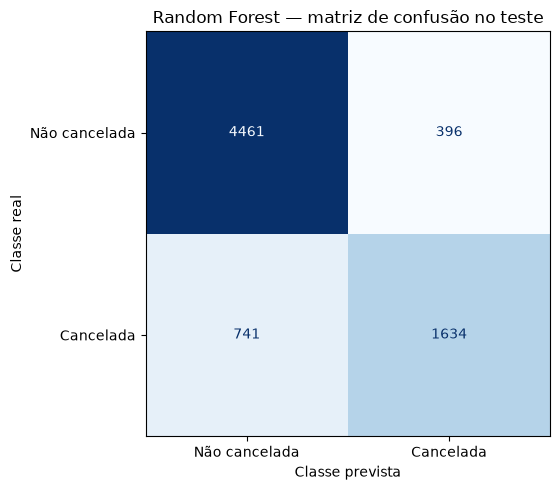

In [167]:
matriz_teste = confusion_matrix(y_teste, previsoes_teste, labels=[0, 1])
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(
    confusion_matrix=matriz_teste,
    display_labels=["Não cancelada", "Cancelada"],
).plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("Random Forest — matriz de confusão no teste")
ax.set_xlabel("Classe prevista")
ax.set_ylabel("Classe real")
plt.tight_layout()
plt.show()

verdadeiros_negativos, falsos_positivos, falsos_negativos, verdadeiros_positivos = matriz_teste.ravel()


### O que entendi da matriz

O modelo acertou **4461 reservas não canceladas** e **1634 reservas canceladas**. Também gerou **396 alertas falsos**, prevendo cancelamento em reservas que não foram canceladas.

Ele deixou passar **741 cancelamentos**, classificando essas reservas como não canceladas. Esses erros mostram que o modelo pode ajudar na organização do hotel, mas ainda precisa de acompanhamento e não deve ser tratado como uma certeza.


### Curva ROC e AUC
A curva ROC mostra a relação entre detectar cancelamentos e gerar alertas falsos em diferentes limites de decisão.
A AUC resume essa capacidade de separação; ela não representa o percentual de previsões corretas.


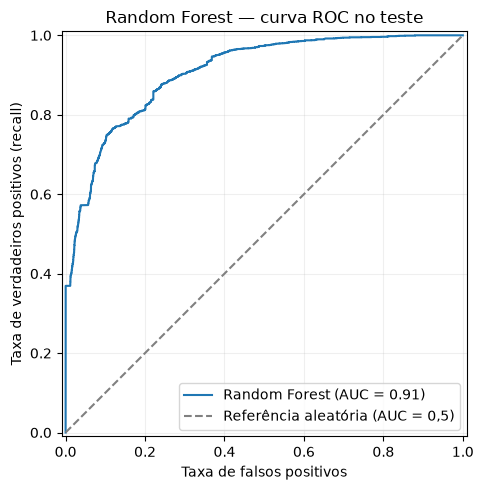

In [168]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(
    y_teste, probabilidades_teste, name="Random Forest", ax=ax,
)
ax.plot([0, 1], [0, 1], "--", color="gray", label="Referência aleatória (AUC = 0,5)")
ax.set_title("Random Forest — curva ROC no teste")
ax.set_xlabel("Taxa de falsos positivos")
ax.set_ylabel("Taxa de verdadeiros positivos (recall)")
ax.legend(loc="lower right")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


### O que entendi da curva ROC

A **AUC foi de 0,91**, acima da referência aleatória de 0,5. Isso indica que o modelo conseguiu separar as classes melhor que essa referência, considerando diferentes limites de decisão.

O limite padrão foi mantido nesta avaliação. Reduzir esse limite pode encontrar mais cancelamentos, mas também gerar mais alertas falsos; qualquer ajuste deve ser escolhido usando o treino, sem buscar um resultado melhor no teste.

Escolhi o **Random Forest** pelo maior F1 médio na validação e apresentei seu resultado final no teste.


## Questão 5 — Exportação e utilização do modelo

### Exportação da Pipeline
Salvei o Random Forest já treinado em `modelo.pkl`, usando joblib, que utiliza um formato baseado em pickle.
A Pipeline inclui a imputação, a transformação das categorias e o classificador, mantendo a preparação usada no treino.


In [169]:
import joblib
from pathlib import Path

caminho_modelo = Path("modelo.pkl")
joblib.dump(modelo_escolhido, caminho_modelo)
print("Modelo exportado:", nome_modelo_escolhido)
print("Arquivo:", caminho_modelo.name)
print("Tamanho do arquivo (MB):", round(caminho_modelo.stat().st_size / (1024 ** 2), 2))


Modelo exportado: Random Forest
Arquivo: modelo.pkl
Tamanho do arquivo (MB): 11.45


### Carregamento e conferência
Recarreguei o arquivo e comparei suas previsões com as do modelo que estava na memória.
Nessa conferência, não treinei novamente nem escolhi parâmetros. Verifiquei se a exportação preservou classes e probabilidades.


In [170]:
import numpy as np

modelo_carregado = joblib.load(caminho_modelo)
classes_carregadas = modelo_carregado.predict(X_teste)
probabilidades_carregadas = modelo_carregado.predict_proba(X_teste)

np.testing.assert_array_equal(classes_carregadas, previsoes_teste)
indice_classe_cancelada = list(modelo_carregado.classes_).index(1)
np.testing.assert_allclose(
    probabilidades_carregadas[:, indice_classe_cancelada],
    probabilidades_teste,
    rtol=0,
    atol=1e-12,
)
print("Conferência concluída: classes e probabilidades foram preservadas.")
print("Etapas carregadas:", list(modelo_carregado.named_steps))


Conferência concluída: classes e probabilidades foram preservadas.
Etapas carregadas: ['preprocessamento', 'classificador']


### Exemplo de uso do modelo exportado
Passei uma reserva com os atributos originais para a Pipeline carregada, sem transformar os dados manualmente.
Deixei o arquivo pronto para a API carregar o modelo ao iniciar a aplicação e prever sem chamar fit a cada requisição.


In [171]:
exemplo_reserva = X_teste.iloc[[0]].copy()
classe_exemplo = int(modelo_carregado.predict(exemplo_reserva)[0])
probabilidade_exemplo = float(
    modelo_carregado.predict_proba(exemplo_reserva)[0, indice_classe_cancelada]
)
rotulos_classes = {0: "Not_Canceled", 1: "Canceled"}

display(exemplo_reserva)
print("Classe prevista:", rotulos_classes[classe_exemplo])
print("Probabilidade estimada de cancelamento:", round(probabilidade_exemplo, 4))


,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,type_of_meal_plan,room_type_reserved,market_segment_type
7,2,0,1,3,0,83,2018,12,26,0,0,0,105.61,1,Meal Plan 1,Room_Type 4,Online


Classe prevista: Not_Canceled
Probabilidade estimada de cancelamento: 0.169


## Questão 6 — API de inferência com Flask

### Aplicação e endpoint
Criei a aplicação em `app.py` e carreguei o `modelo.pkl` ao iniciar. Implementei `POST /predict` para receber uma reserva em JSON.
Usei a Pipeline exportada para aplicar a mesma preparação do treino e retornar a classe prevista, sem novo treinamento.

### Exemplo de entrada
Enviei os 17 atributos usados no modelo, sem o identificador e sem o alvo. Usei números para as colunas numéricas e textos para as categorias.
Conferi os campos obrigatórios, a data e os valores básicos antes da previsão; categorias novas seguem o tratamento do encoder.


In [172]:
reserva_api = {'no_of_adults': 2,
 'no_of_children': 0,
 'no_of_weekend_nights': 1,
 'no_of_week_nights': 2,
 'required_car_parking_space': 0,
 'lead_time': 60,
 'arrival_year': 2018,
 'arrival_month': 10,
 'arrival_date': 15,
 'repeated_guest': 0,
 'no_of_previous_cancellations': 0,
 'no_of_previous_bookings_not_canceled': 0,
 'avg_price_per_room': 100.0,
 'no_of_special_requests': 1,
 'type_of_meal_plan': 'Meal Plan 1',
 'room_type_reserved': 'Room_Type 1',
 'market_segment_type': 'Online'}


### Conferência da requisição
Testei o endpoint com o cliente de testes do Flask, sem iniciar um servidor dentro do notebook.
A resposta contém a classe (0 ou 1), o nome da classe e a probabilidade estimada de cancelamento.


In [173]:
from app import app

with app.test_client() as cliente:
    resposta_api = cliente.post("/predict", json=reserva_api)

print("Status HTTP:", resposta_api.status_code)
print("Resposta JSON:", resposta_api.get_json())
assert resposta_api.status_code == 200


Status HTTP: 200
Resposta JSON: {'booking_status': 'Not_Canceled', 'classe': 0, 'probabilidade_cancelamento': 0.2042}


### Execução e exemplo com curl
Registrei os comandos para iniciar a API em um terminal e enviar a reserva em outro, a partir da pasta do projeto.
O curl abaixo usa os mesmos atributos do exemplo conferido no notebook.

**No primeiro terminal:**
```bash
.venv/bin/python app.py
```

**No segundo terminal:**
```bash
curl -X POST http://localhost:5000/predict \
  -H 'Content-Type: application/json' \
  -d '
{
  "no_of_adults": 2,
  "no_of_children": 0,
  "no_of_weekend_nights": 1,
  "no_of_week_nights": 2,
  "required_car_parking_space": 0,
  "lead_time": 60,
  "arrival_year": 2018,
  "arrival_month": 10,
  "arrival_date": 15,
  "repeated_guest": 0,
  "no_of_previous_cancellations": 0,
  "no_of_previous_bookings_not_canceled": 0,
  "avg_price_per_room": 100.0,
  "no_of_special_requests": 1,
  "type_of_meal_plan": "Meal Plan 1",
  "room_type_reserved": "Room_Type 1",
  "market_segment_type": "Online"
}
'
```

**Resposta obtida para esse exemplo:**
```json
{
  "booking_status": "Not_Canceled",
  "classe": 0,
  "probabilidade_cancelamento": 0.2042
}
```


### Interface para testar a API

Criei uma página HTML com um formulário para facilitar o teste pelo navegador. Usei CSS para o visual e JavaScript para enviar os dados ao endpoint POST /predict.

O formulário mostra a classe prevista e a probabilidade estimada de cancelamento. Mantive a API funcionando também pelo comando curl.


## Questão 7 — Docker, reprodutibilidade e organização

### Docker
Criei o Dockerfile com Python 3.12 e as dependências da aplicação. Incluí a API, o modelo treinado e os arquivos da interface.
Configurei o Compose para iniciar a aplicação na porta 5000, sem realizar novo treinamento.

Registrei no README o comando de execução pedido na avaliação e a alternativa para instalações recentes do Compose:

```bash
docker-compose up -d --build
# Alternativa: docker compose up -d --build
```

A interface fica em **http://localhost:5000/** e a API recebe requisições em **POST /predict**. Expliquei no README como consultar os logs, encerrar a aplicação e usar outra porta.

### Reprodutibilidade
Registrei as versões das bibliotecas em `requirements.txt` e as dependências do notebook em `requirements-treinamento.txt`.
Mantive o dataset e o modelo exportado na entrega. Expliquei como executar as células em ordem para reproduzir o treinamento, a avaliação e a exportação.

### README e organização
Organizei o notebook, o dataset, o modelo, a API, os arquivos Docker e as pastas `templates/` e `static/`.
Escrevi no README a origem dos dados, a metodologia, os resultados e os passos para baixar, executar e testar o projeto, incluindo uma requisição e sua resposta.

### Verificação
Construí a imagem Docker e conferi a página e a API dentro do contêiner. A verificação de saúde passou e os arquivos da interface responderam com HTTP 200.
No exemplo de reserva, recebi `Not_Canceled` e probabilidade de cancelamento de `0.2042`, igual ao resultado conferido anteriormente.
